# Temporal Fusion Transformer with PCA and Bayesian Hyperparameter Tuning

This notebook trains a Temporal Fusion Transformer model on the total consumption dataset, using PCA for feature extraction, and employs Optuna for Bayesian hyperparameter optimization.

In [3]:
import importlib.util
import subprocess
import sys
import warnings
warnings.filterwarnings('ignore')
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
import optuna
from optuna.integration import PyTorchLightningPruningCallback

pl.seed_everything(42, workers=True)
np.random.seed(42)
torch.manual_seed(42)

Seed set to 42


In [4]:
data_path = '../../total_consumption_data.csv'
df = pd.read_csv(data_path)
df.columns = [c.strip() for c in df.columns]

if np.issubdtype(df['datetime'].dtype, np.number):
    df['datetime'] = pd.to_datetime(df['datetime'], unit='s', errors='coerce')
else:
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

for col in df.columns:
    if col not in ['datetime', 'meter_id']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values(['meter_id', 'datetime']).reset_index(drop=True)

num_cols = [c for c in df.columns if c not in ['datetime', 'meter_id']]
df[num_cols] = df.groupby('meter_id')[num_cols].ffill()
df[num_cols] = df.groupby('meter_id')[num_cols].bfill()

drop_cols = [
    'aenergy_ph2', 'aenergy_ph3', 'renergy_ph2', 'renergy_ph3',
    'apower_ph2', 'apower_ph3', 'rpower_ph2', 'rpower_ph3',
    'current_ph2', 'current_ph3', 'pfactor_ph2', 'pfactor_ph3',
    'voltage_ph2', 'voltage_ph3', 'apower', 'pfactor',
]
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

num_cols = [c for c in df.columns if c not in ['datetime', 'meter_id']]
zero_cols = [c for c in num_cols if np.isclose(df[c].fillna(0).abs().sum(), 0)]
if zero_cols:
    df = df.drop(columns=zero_cols)

meter_ids = sorted(df['meter_id'].dropna().unique().tolist())
meter_map = {m: f'M{i:03d}' for i, m in enumerate(meter_ids)}
df['meter_label'] = df['meter_id'].map(meter_map).fillna('UNK')
df = df.dropna(subset=['datetime', 'meter_id']).copy()

In [5]:
df_fe = df.copy()

df_fe['apparent_power_ph1'] = df_fe['voltage_ph1'] * df_fe['current_ph1']
df_fe['pf_angle_ph1'] = np.arccos(np.clip(df_fe['pfactor_ph1'], -1, 1))
df_fe['energy_intensity'] = df_fe['aenergy_ph1'] / (df_fe['apparent_power_ph1'].abs() + 1e-6)
df_fe['Q_P_ratio'] = df_fe['rpower_ph1'] / (df_fe['apower_ph1'].abs() + 1e-6)
df_fe['hour'] = df_fe['datetime'].dt.hour.astype('int16')
df_fe['dayofweek'] = df_fe['datetime'].dt.dayofweek.astype('int16')
df_fe['is_weekend'] = (df_fe['dayofweek'] >= 5).astype('int8')
df_fe['is_peak'] = df_fe['hour'].between(8, 20).astype('int8')
df_fe['apower_roll3'] = (
    df_fe.groupby('meter_id')['apower_ph1']
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

base_feature_cols = [
    'aenergy', 'aenergy_ph1', 'renergy', 'renergy_ph1',
    'apower_ph1', 'rpower_ph1', 'current_ph1', 'pfactor_ph1', 'voltage_ph1',
    'apparent_power_ph1', 'pf_angle_ph1', 'energy_intensity', 'Q_P_ratio',
    'hour', 'dayofweek', 'is_weekend', 'is_peak', 'apower_roll3',
]

base_feature_cols = [c for c in base_feature_cols if c in df_fe.columns]
target_col = 'apower_ph1'

df_fe = df_fe.replace([np.inf, -np.inf], np.nan)
numeric_fill_cols = list(set(base_feature_cols + [target_col]))
for c in numeric_fill_cols:
    df_fe[c] = pd.to_numeric(df_fe[c], errors='coerce')
df_fe[numeric_fill_cols] = df_fe[numeric_fill_cols].fillna(df_fe[numeric_fill_cols].median(numeric_only=True))

df_fe = df_fe.sort_values(['meter_id', 'datetime']).reset_index(drop=True)
df_fe['time_idx'] = df_fe.groupby('meter_id').cumcount()
group_max_idx = df_fe.groupby('meter_id')['time_idx'].max()
train_cutoffs = (group_max_idx * 0.70).astype(int)
val_cutoffs = (group_max_idx * 0.85).astype(int)
df_fe['train_cutoff'] = df_fe['meter_id'].map(train_cutoffs)
df_fe['val_cutoff'] = df_fe['meter_id'].map(val_cutoffs)

cont_for_pca = [c for c in base_feature_cols if c not in ['hour', 'dayofweek', 'is_weekend', 'is_peak']]
train_mask = df_fe['time_idx'] <= df_fe['train_cutoff']

scaler = StandardScaler()
X_train = scaler.fit_transform(df_fe.loc[train_mask, cont_for_pca])
X_all = scaler.transform(df_fe[cont_for_pca])

pca_n_components = min(12, len(cont_for_pca))
pca = PCA(n_components=pca_n_components, random_state=42)
pca.fit(X_train)
X_pca_all = pca.transform(X_all)

pca_cols = [f'pca_{i+1}' for i in range(pca_n_components)]
for i, c in enumerate(pca_cols):
    df_fe[c] = X_pca_all[:, i]

feature_cols = base_feature_cols + pca_cols

max_encoder_length = 24
max_prediction_length = 1
min_len = max_encoder_length + max_prediction_length + 1
valid_meters = df_fe.groupby('meter_id').size()
valid_meters = valid_meters[valid_meters >= min_len].index
df_fe = df_fe[df_fe['meter_id'].isin(valid_meters)].copy()

In [6]:
train_df = df_fe[df_fe['time_idx'] <= df_fe['train_cutoff']].copy()
val_df = df_fe[df_fe['time_idx'] <= df_fe['val_cutoff']].copy()
test_df = df_fe.copy()

known_reals = ['time_idx', 'hour', 'dayofweek', 'is_weekend', 'is_peak']
unknown_reals = [c for c in feature_cols if c not in known_reals]
if target_col not in unknown_reals:
    unknown_reals = [target_col] + unknown_reals

training = TimeSeriesDataSet(
    train_df,
    time_idx='time_idx',
    target=target_col,
    group_ids=['meter_id'],
    static_categoricals=['meter_label'],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    target_normalizer=GroupNormalizer(groups=['meter_id']),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(training, val_df, stop_randomization=True)
testing = TimeSeriesDataSet.from_dataset(training, test_df, stop_randomization=True)

train_loader = training.to_dataloader(train=True, batch_size=128, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=256, num_workers=0)
test_loader = testing.to_dataloader(train=False, batch_size=256, num_workers=0)

## Bayesian Hyperparameter Optimization with Optuna

In [7]:
def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    hidden_size = trial.suggest_categorical("hidden_size", [16, 32, 64])
    attention_head_size = trial.suggest_categorical("attention_head_size", [1, 4])
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    hidden_continuous_size = trial.suggest_categorical("hidden_continuous_size", [8, 16, 32])

    tft = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=learning_rate,
        hidden_size=hidden_size,
        attention_head_size=attention_head_size,
        dropout=dropout,
        hidden_continuous_size=hidden_continuous_size,
        output_size=7,
        loss=QuantileLoss(),
        reduce_on_plateau_patience=3,
    )

    accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
    early_stop = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=3, mode='min')
    prune_callback = PyTorchLightningPruningCallback(trial, monitor="val_loss")

    trainer = pl.Trainer(
        max_epochs=5, # Keep small for optimization
        accelerator=accelerator,
        devices=1,
        gradient_clip_val=0.1,
        callbacks=[early_stop, prune_callback],
        logger=False,
        enable_checkpointing=False,
        enable_model_summary=False,
        enable_progress_bar=False
    )

    trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)
    
    return trainer.callback_metrics["val_loss"].item()

study = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=10, timeout=1200) # Quick search

print(f"Best trial: {study.best_trial.value}")
print("Best hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

[I 2026-04-18 18:10:01,180] A new study created in memory with name: no-name-b2191b85-2e7e-483e-814a-92f013aa854c
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=5` reached.
[I 2026-04-18 18:17:49,278] Trial 0 finished with value: 65.9957275390625 and parameters: {'learning_rate': 0.00

Best trial: 63.181915283203125
Best hyperparameters:
  learning_rate: 0.008030084414122835
  hidden_size: 16
  attention_head_size: 1
  dropout: 0.1952512920906661
  hidden_continuous_size: 16


## Final Training Using Best Parameters

In [8]:
best_params = study.best_trial.params

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=best_params["learning_rate"],
    hidden_size=best_params["hidden_size"],
    attention_head_size=best_params["attention_head_size"],
    dropout=best_params["dropout"],
    hidden_continuous_size=best_params["hidden_continuous_size"],
    output_size=7,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=3,
)

accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
early_stop = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=5, mode='min')

trainer = pl.Trainer(
    max_epochs=15,
    accelerator=accelerator,
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop],
    logger=False,
    enable_checkpointing=True,
    enable_model_summary=True,
)

trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

best_ckpt = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_ckpt)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


In [9]:
def flatten_targets(raw_target):
    if isinstance(raw_target, (list, tuple)):
        arr = raw_target[0]
    else:
        arr = raw_target
    if hasattr(arr, 'detach'):
        arr = arr.detach().cpu().numpy()
    return np.asarray(arr).reshape(-1)

def collect_true_pred(model, loader):
    preds = model.predict(loader).detach().cpu().numpy().reshape(-1)
    trues = []
    for _, y in loader:
        trues.append(flatten_targets(y))
    trues = np.concatenate(trues, axis=0)[:len(preds)]
    return trues, preds

def regression_metrics(y_true, y_pred):
    eps = 1e-6
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100.0)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE(%)': mape}

val_true, val_pred = collect_true_pred(best_tft, val_loader)
test_true, test_pred = collect_true_pred(best_tft, test_loader)

metrics_df = pd.DataFrame([
    regression_metrics(val_true, val_pred),
    regression_metrics(test_true, test_pred),
], index=['Validation', 'Test'])

print(metrics_df)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

                  MAE        RMSE        R2    MAPE(%)
Validation  86.400719  265.012883  0.867257  26.418152
Test        84.432785  261.282100  0.863005  27.760559


In [1]:
import matplotlib.pyplot as plt

# Plot continuous actual vs predicted series over a specific time frame
time_frame = 3000  # Number of initial test time steps to plot (e.g., first few days/weeks of the first meter)

plt.figure(figsize=(16, 5))
plt.plot(test_true[:time_frame], label="Actual (Ground Truth)", color="royalblue", alpha=0.9, lw=1.5)
plt.plot(test_pred[:time_frame], label="Predicted (TFT Forecast)", color="darkorange", alpha=0.8, lw=1.5)

plt.xlabel("Time Steps")
plt.ylabel("apower_ph1")
plt.title(f"TFT Predictions vs Actuals Over Time (First {time_frame} steps of Test Set)")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

NameError: name 'test_true' is not defined

<Figure size 1600x500 with 0 Axes>

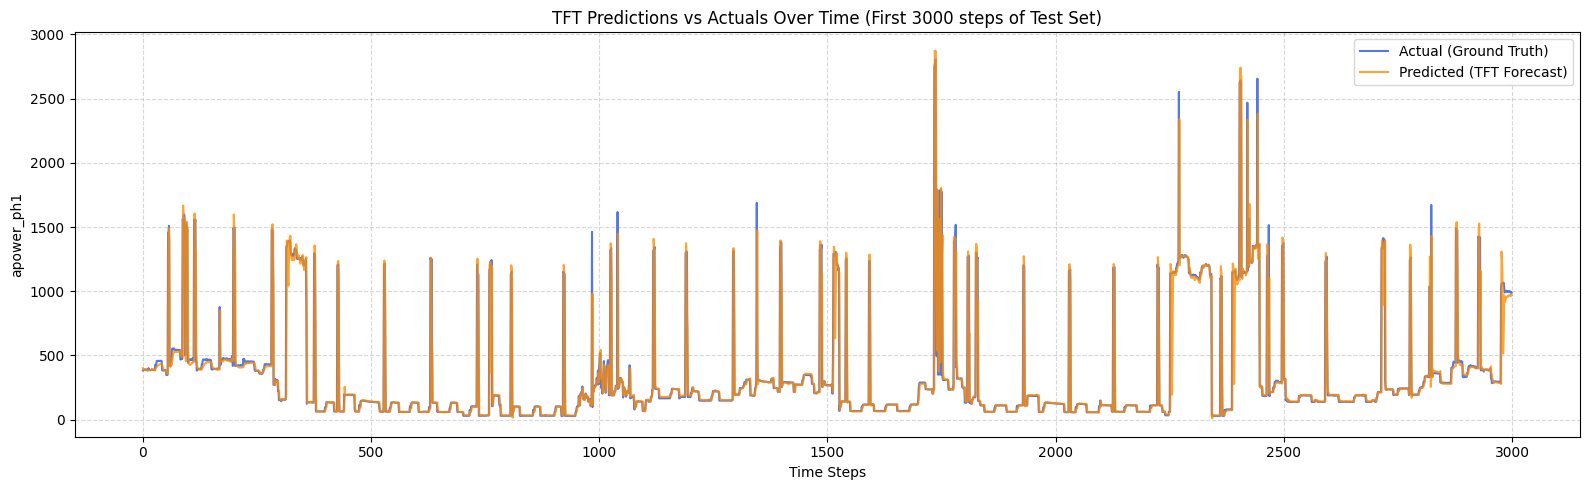

In [13]:
# Plot continuous actual vs predicted series over a specific time frame
time_frame = 3000  # Number of initial test time steps to plot (e.g., first few days/weeks of the first meter)

plt.figure(figsize=(16, 5))
plt.plot(test_true[:time_frame], label="Actual (Ground Truth)", color="royalblue", alpha=0.9, lw=1.5)
plt.plot(test_pred[:time_frame], label="Predicted (TFT Forecast)", color="darkorange", alpha=0.8, lw=1.5)

plt.xlabel("Time Steps")
plt.ylabel("apower_ph1")
plt.title(f"TFT Predictions vs Actuals Over Time (First {time_frame} steps of Test Set)")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()